In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import jax as jx
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

print(project_root)

import aymansigmri as asm

/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE


## Goal: Implement Algorithm 4.1

In [2]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

### Set up ZTE style data

In [3]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

### Build and plot mask - same as in cartesian testing

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


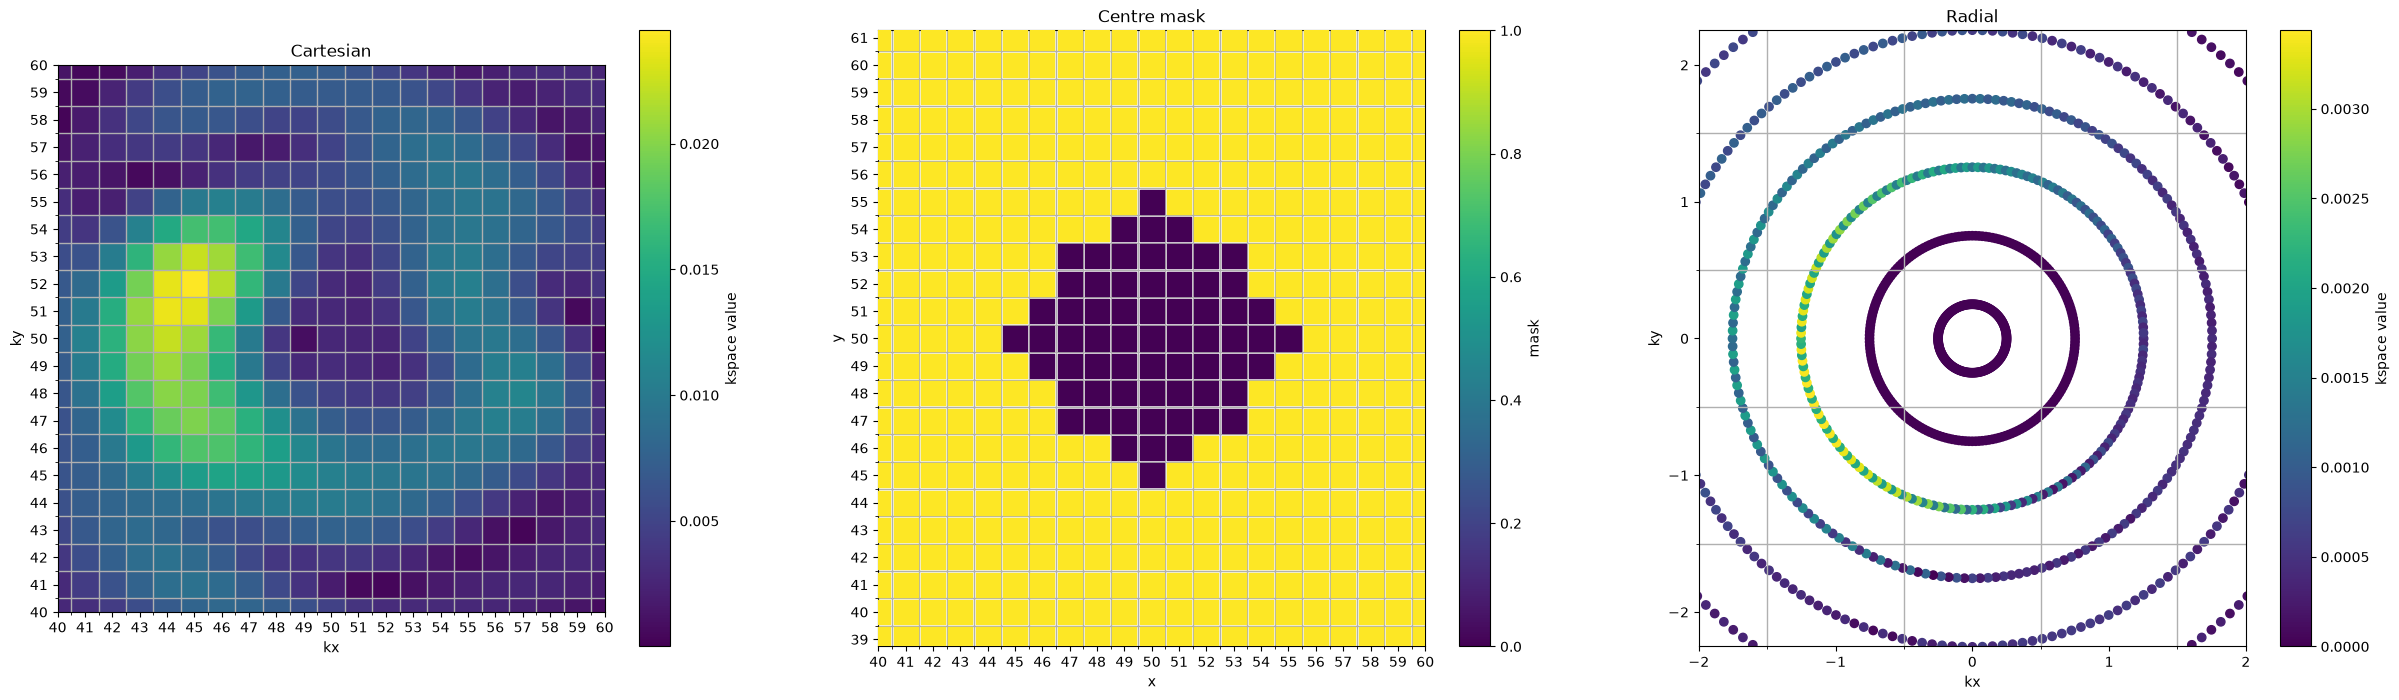

In [4]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


asm.plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

### Functions for inner loop and filling framework

In [91]:
def softimpute_ALS(X_H, M_H, rank, lamda, n_iters):
        I = np.eye(rank)
        m,n = np.shape(X_H)
        U = np.random.randn(m, rank) + 1j * np.random.randn(m, rank)
        V = np.random.randn(n, rank) + 1j * np.random.randn(n, rank)

        D = I.copy()


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        while iter_count < n_iters:
            X_star = M_H * (X_H - A @ B.conj().T) #+ A @ B.conj().T

            B2 = np.linalg.inv(B.conj().T @ B + lamda*I)

            A = X_star @ B @ B2

            X_star = M_H * (X_H - A @ B.conj().T) #+ A @ B.conj().T

            A2 = np.linalg.inv(A.conj().T @ A + lamda*I)

            B = X_star.conj().T @ A @ A2

            ABt = A @ B.conj().T

            iter_count +=1
        return(ABt)

def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_zerod = ksp_forhankel * dtg_mask
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_zerod, w=window_size)
    mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = asm.hankel(mask_coiled, window_size)
    masked_hankel = np.real(masked_hankel) > 0.5

    
    
    filled_hankel = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters)
    
    kspace_cart_coils_recon = asm.hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
    #kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output_kspace = kspace_cart_coils_recon.copy()
    return output_kspace

## Testing

In [107]:
window_size = 5
matrix_rank = 250
lamda = 10**-6
ksp_forhankel = inner_region.copy()
num_iters = 32

output_kspace = LORAKS_imputeals(n_iters=num_iters, window_size=window_size, cartesian_inputkspace=inner_region, dtg_mask=mask, rank= matrix_rank, lamda = lamda)
recombined = asm.jigsaw(output_kspace=output_kspace, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
cartesian_kspace_rebuild = asm.zero_padding(recombined, 256,256)
post_loop_kspace = cartesian_kspace_rebuild.copy()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


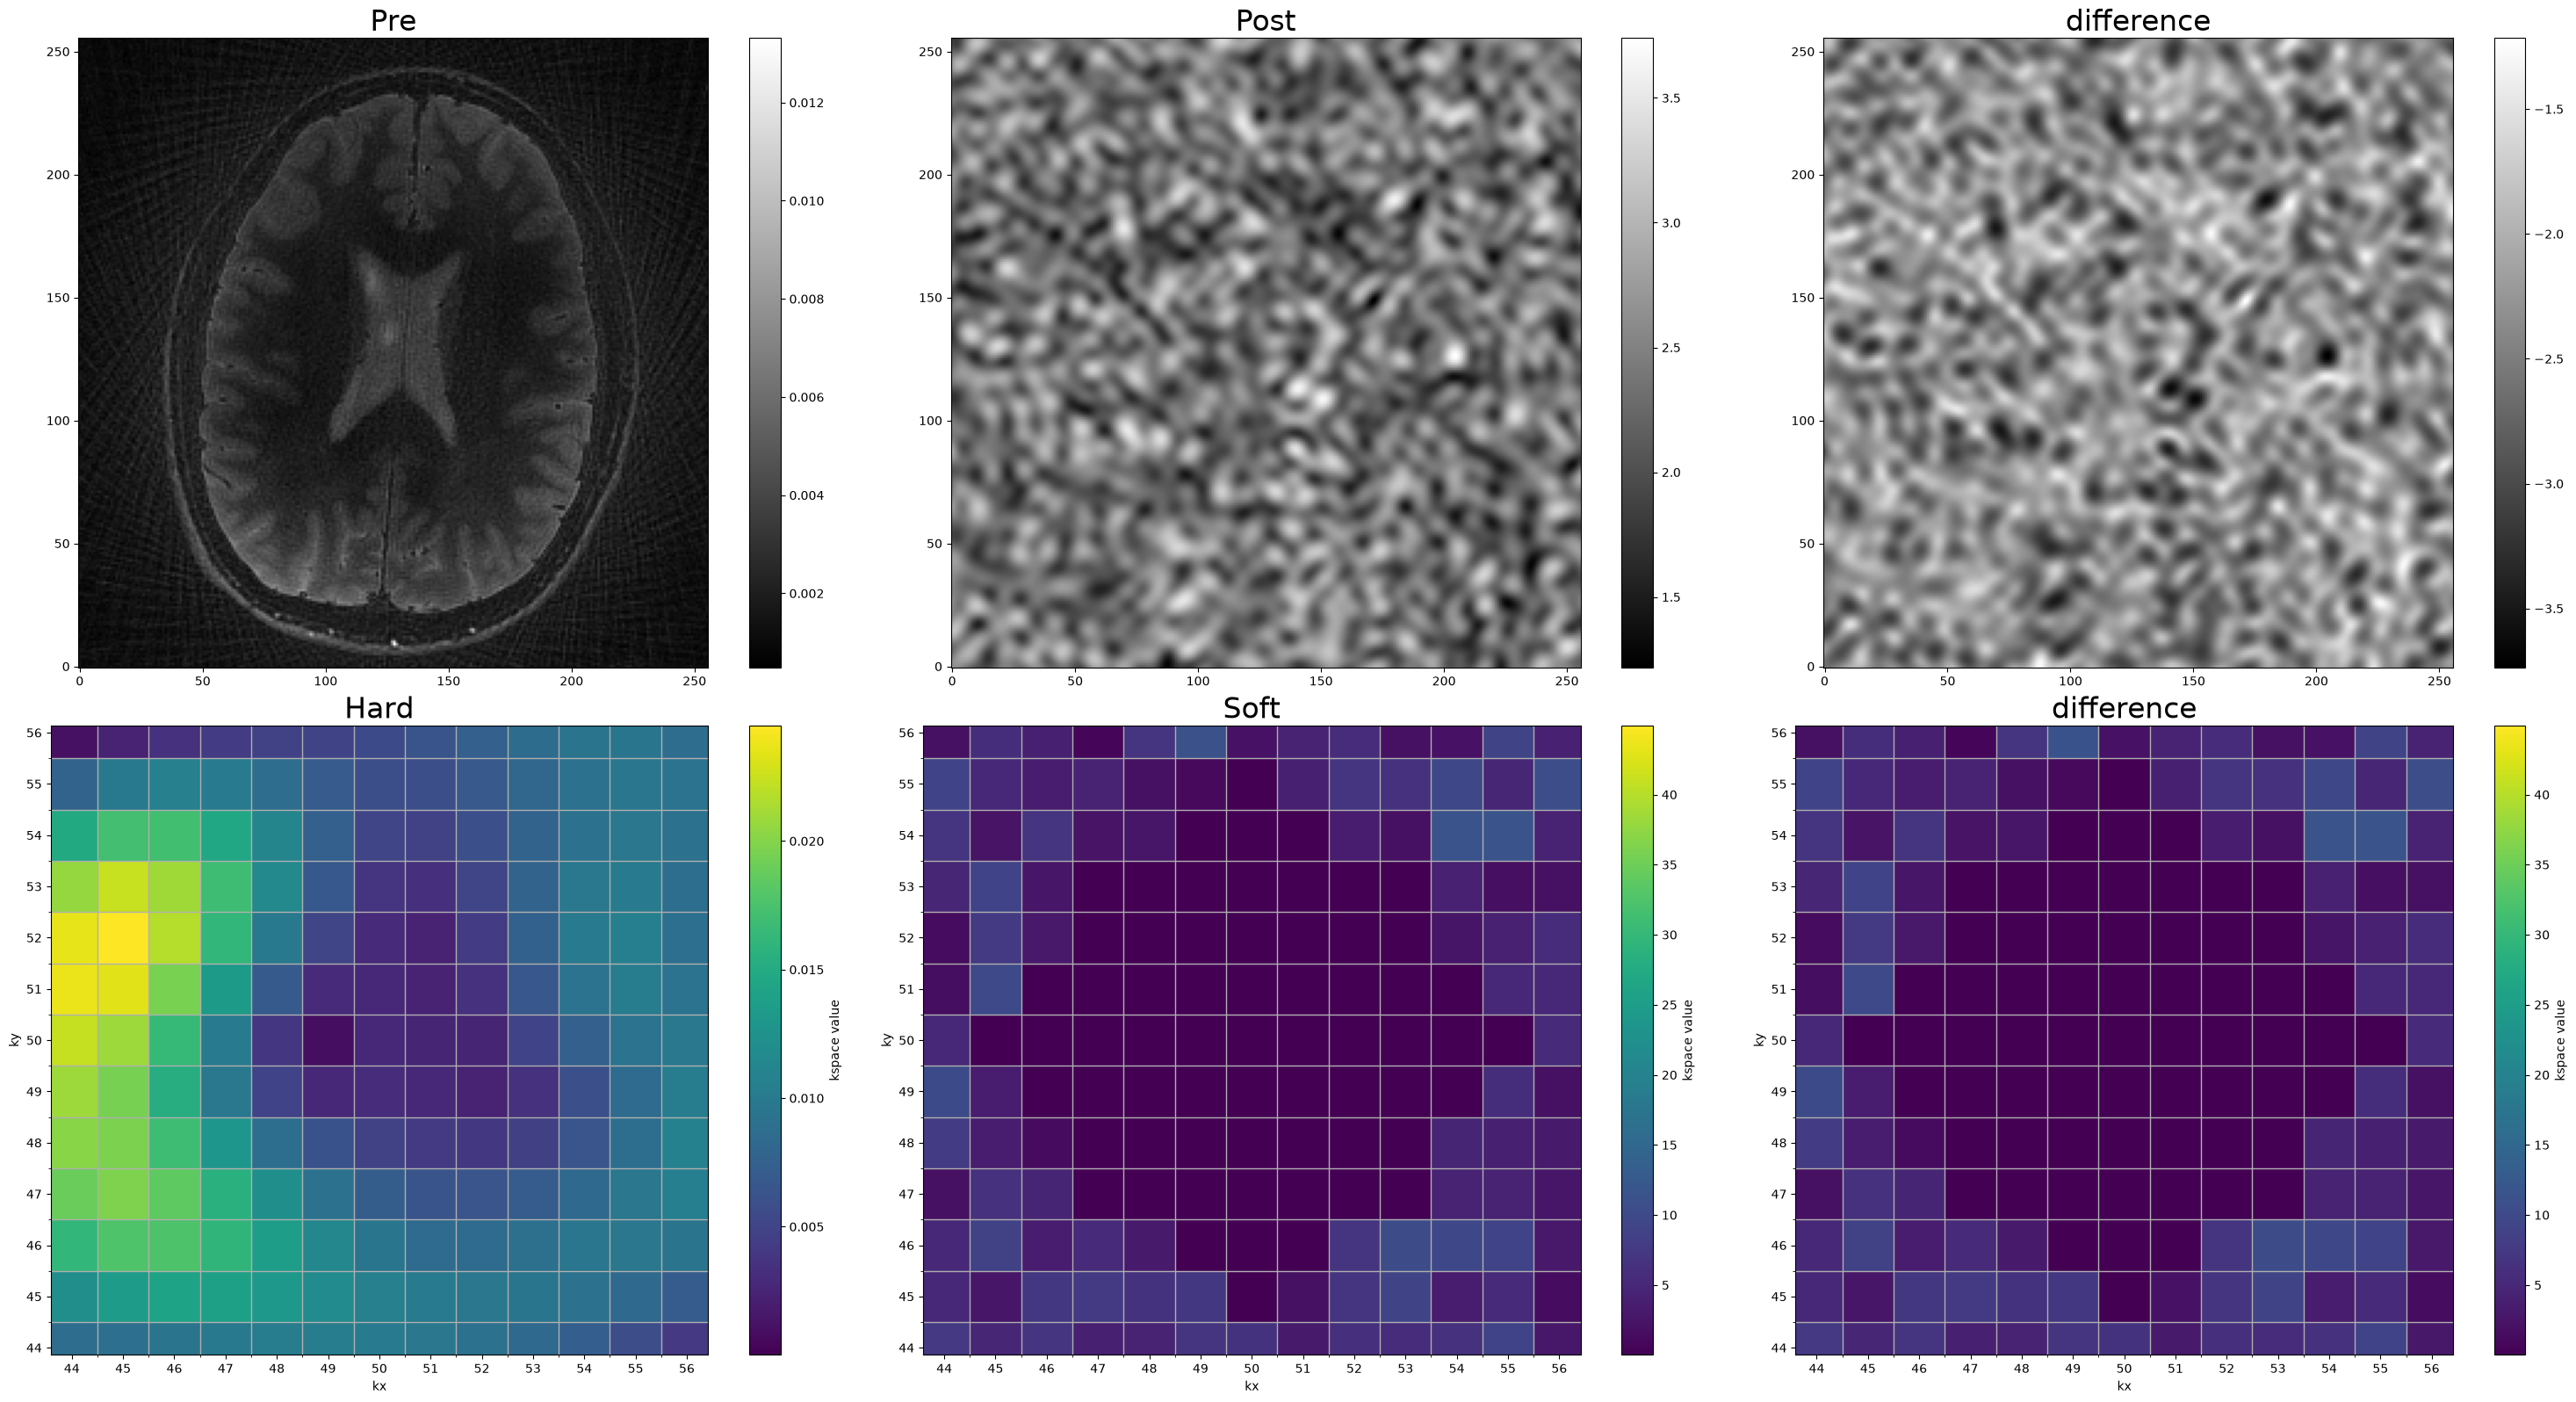

In [108]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(30, 16))


im1 = np.sum(np.abs(sp.ifft(cartesian_zte))**2, axis=0)**0.5
p1 = ax[0, 0].imshow(im1, cmap='gray', origin='lower')
ax[0, 0].set_title(f'Pre', fontsize=24)
fig.colorbar(p1, ax=ax[0, 0])


im2_soft = np.sum(np.abs(sp.ifft(post_loop_kspace))**2, axis=0)**0.5
p1_soft = ax[0, 1].imshow(im2_soft, cmap='gray', origin='lower')
ax[0, 1].set_title(f'Post', fontsize=24)
fig.colorbar(p1_soft, ax=ax[0, 1])


p2 = ax[0, 2].imshow(im1-im2_soft, cmap='gray', origin='lower')
ax[0, 2].set_title('difference', fontsize=24)
fig.colorbar(p2, ax=ax[0, 2])



im1k = ax[1, 0].imshow(np.abs(inner_region[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k, ax=ax[1, 0], label='kspace value')
ax[1, 0].set_title(f'Hard', fontsize=24)
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 0].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im1k_soft = ax[1, 1].imshow(np.abs(output_kspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k_soft, ax=ax[1, 1], label='kspace value')
ax[1, 1].set_title(f'Soft', fontsize=24)
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 1].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))


diff = inner_region - output_kspace

im2k = ax[1, 2].imshow(np.abs(diff[0]), cmap='viridis', origin='lower')
fig.colorbar(im2k, ax=ax[1, 2], label='kspace value')
ax[1, 2].set_title('difference', fontsize=24)
ax[1, 2].set_xlabel('kx')
ax[1, 2].set_ylabel('ky')
ax[1, 2].axis('equal')
ax[1, 2].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 2].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].grid(visible=True, which='minor', linewidth=1)
ax[1, 2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

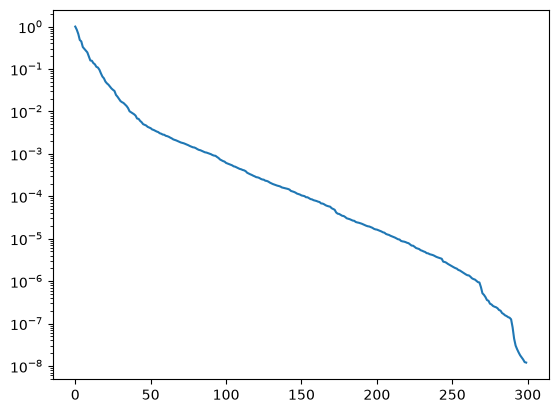

In [104]:
## Find rank of matrix

X_H, n_coils, Numx, Numy = asm.hankel(kspace=inner_region, w=5)
sv = np.linalg.svd(X_H, compute_uv=False)
plt.semilogy(sv / sv[0])